Columns: Index(['chan_id', 'spacecraft', 'anomaly_sequences', 'class', 'num_values'], dtype='object')
  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                              [[5300, 5747]]   
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]   
3     E-2       SMAP                              [[5598, 6995]]   
4     E-3       SMAP                              [[5094, 8306]]   

                                  class  num_values  
0  [contextual, contextual, contextual]        8505  
1                               [point]        7331  
2              [contextual, contextual]        8516  
3                               [point]        8532  
4                               [point]        8307  

Channel: P-1
Anomaly sequences: [[2149, 2349], [4536, 4844], [3539, 3779]]
Signal shape: (2872, 25)


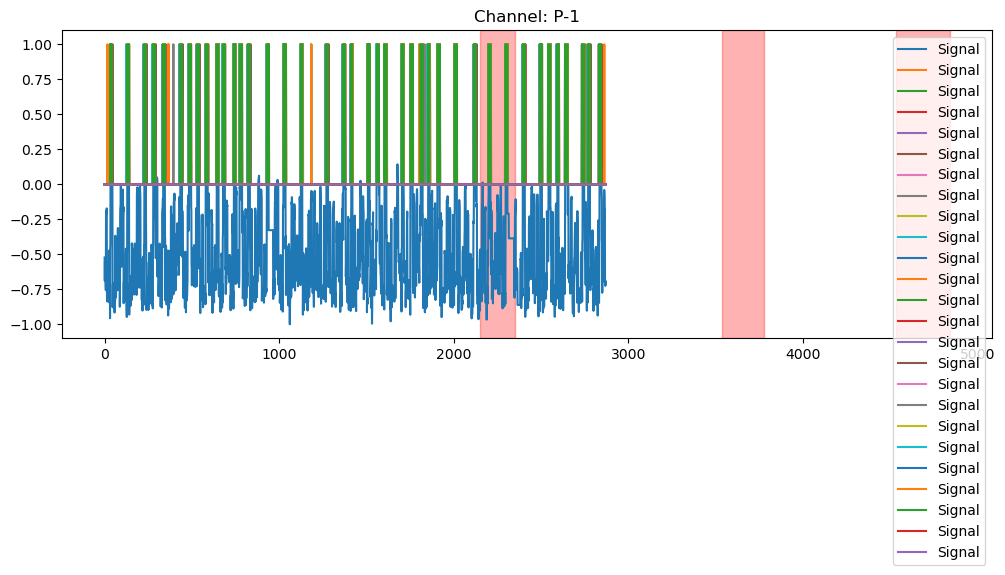

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load anomaly labels
labels_path = r"C:\Users\aryan\Downloads\labeled_anomalies.csv"
labels_df = pd.read_csv(labels_path)

print("Columns:", labels_df.columns)
print(labels_df.head())

# 2. Pick one example (first row)
row = labels_df.iloc[0]

chan_id = row['chan_id']
anomaly_sequences = eval(row['anomaly_sequences'])  # convert string to list

print("\nChannel:", chan_id)
print("Anomaly sequences:", anomaly_sequences)

# 3. Load corresponding signal (.npy file)
data_path="C:\\Users\\aryan\\Downloads\\Dataset for satellite anomaly\\data\\data\\train"
signal = np.load(f"{data_path}/{chan_id}.npy")

print("Signal shape:", signal.shape)

# 4. Plot signal
plt.figure(figsize=(12,4))
plt.plot(signal, label="Signal")

# 5. Mark anomalies
for seq in anomaly_sequences:
    start, end = seq
    plt.axvspan(start, end, color='red', alpha=0.3)

plt.title(f"Channel: {chan_id}")
plt.legend()
plt.show()

In [5]:
anomaly_sequences 

[[2149, 2349], [4536, 4844], [3539, 3779]]

In [10]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. LOAD ALL CHANNELS
# -----------------------------

data_path = r"C:\Users\aryan\Downloads\Dataset for satellite anomaly\data\data\train"

files = os.listdir(data_path)

signals = []
valid_files = []

for file in files:
    if file.endswith(".npy"):
        s = np.load(os.path.join(data_path, file))
        
        # ensure it's 1D
        if len(s.shape) == 1:
            signals.append(s)
            valid_files.append(file)

print("Total channels loaded:", len(signals))



Total channels loaded: 0


ValueError: min() iterable argument is empty

In [11]:
data_path

'C:\\Users\\aryan\\Downloads\\Dataset for satellite anomaly\\data\\data\\train'

In [12]:
print(files)

['A-1.npy', 'A-2.npy', 'A-3.npy', 'A-4.npy', 'A-5.npy', 'A-6.npy', 'A-7.npy', 'A-8.npy', 'A-9.npy', 'B-1.npy', 'C-1.npy', 'C-2.npy', 'D-1.npy', 'D-11.npy', 'D-12.npy', 'D-13.npy', 'D-14.npy', 'D-15.npy', 'D-16.npy', 'D-2.npy', 'D-3.npy', 'D-4.npy', 'D-5.npy', 'D-6.npy', 'D-7.npy', 'D-8.npy', 'D-9.npy', 'E-1.npy', 'E-10.npy', 'E-11.npy', 'E-12.npy', 'E-13.npy', 'E-2.npy', 'E-3.npy', 'E-4.npy', 'E-5.npy', 'E-6.npy', 'E-7.npy', 'E-8.npy', 'E-9.npy', 'F-1.npy', 'F-2.npy', 'F-3.npy', 'F-4.npy', 'F-5.npy', 'F-7.npy', 'F-8.npy', 'G-1.npy', 'G-2.npy', 'G-3.npy', 'G-4.npy', 'G-6.npy', 'G-7.npy', 'M-1.npy', 'M-2.npy', 'M-3.npy', 'M-4.npy', 'M-5.npy', 'M-6.npy', 'M-7.npy', 'P-1.npy', 'P-10.npy', 'P-11.npy', 'P-14.npy', 'P-15.npy', 'P-2.npy', 'P-3.npy', 'P-4.npy', 'P-7.npy', 'R-1.npy', 'S-1.npy', 'S-2.npy', 'T-1.npy', 'T-10.npy', 'T-12.npy', 'T-13.npy', 'T-2.npy', 'T-3.npy', 'T-4.npy', 'T-5.npy', 'T-8.npy', 'T-9.npy']


In [14]:
signals = []

for file in files:
    if file.endswith(".npy"):
        s = np.load(os.path.join(data_path, file))
        
        # Convert all to 1D
        if len(s.shape) == 2:
            s = s.flatten()
        
        signals.append(s)

print("Total signals loaded:", len(signals))

Total signals loaded: 82


In [15]:

# -----------------------------
# 2. FIX SHAPE ISSUE (TRIM)
# -----------------------------

min_len = min(len(s) for s in signals)

signals_trimmed = [s[:min_len] for s in signals]

# Stack → (time_steps, features)
data = np.stack(signals_trimmed, axis=1)

print("Final data shape:", data.shape)


Final data shape: (7800, 82)


In [22]:
data2 = np.stack(signals_trimmed, axis=1)


In [24]:
print("Final data shape:", data2.shape)

Final data shape: (7800, 82)


In [20]:
print(data.max())

4.162651279553374


In [21]:
print(data.min())

-1.2258638886296247


Total anomalies detected: 78


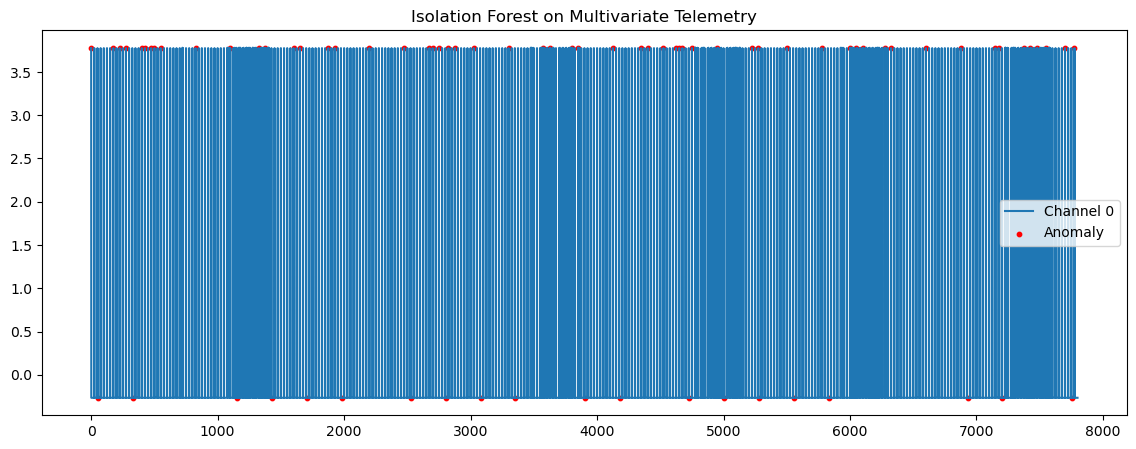

In [32]:


# -----------------------------
# 3. NORMALIZE
# -----------------------------

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


# -----------------------------
# 4. ISOLATION FOREST
# -----------------------------

model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

model.fit(data_scaled)


# -----------------------------
# 5. PREDICT
# -----------------------------

preds = model.predict(data_scaled)

# Convert to 1 (anomaly) / 0 (normal)
anomaly = np.where(preds == -1, 1, 0)

print("Total anomalies detected:", np.sum(anomaly))


# -----------------------------
# 6. VISUALIZATION
# -----------------------------

plt.figure(figsize=(14,5))

# Plot first channel
plt.plot(data_scaled[:, 0], label="Channel 0")

# Mark anomalies
anomaly_idx = np.where(anomaly == 1)[0]
plt.scatter(anomaly_idx, data_scaled[anomaly_idx, 0],
            color='red', s=10, label="Anomaly")

plt.title("Isolation Forest on Multivariate Telemetry")
plt.legend()
plt.show()

Total anomalies: 78

Anomaly at time 0
Most deviating feature: 10
Deviation value: 12.081
Anomaly likely started at: 0


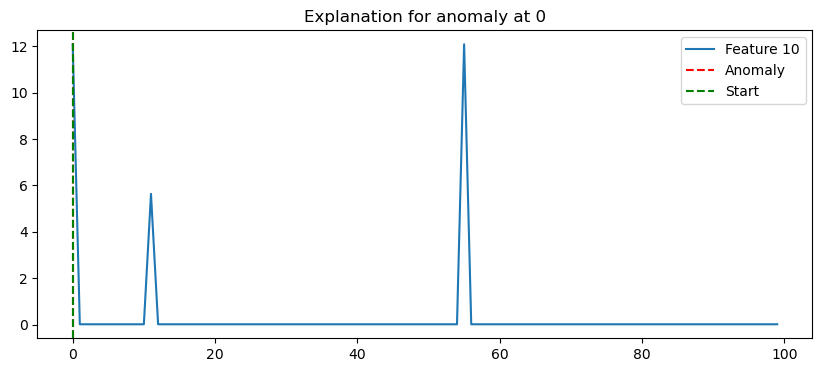


Anomaly at time 55
Most deviating feature: 10
Deviation value: 12.081
Anomaly likely started at: 55


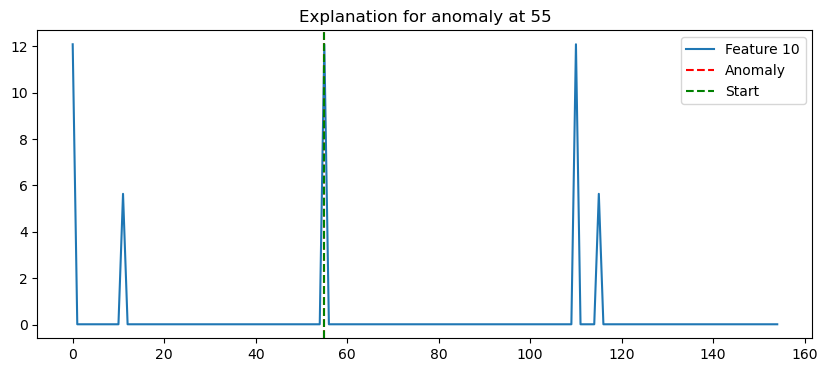


Anomaly at time 175
Most deviating feature: 70
Deviation value: 6.276
Anomaly likely started at: 175


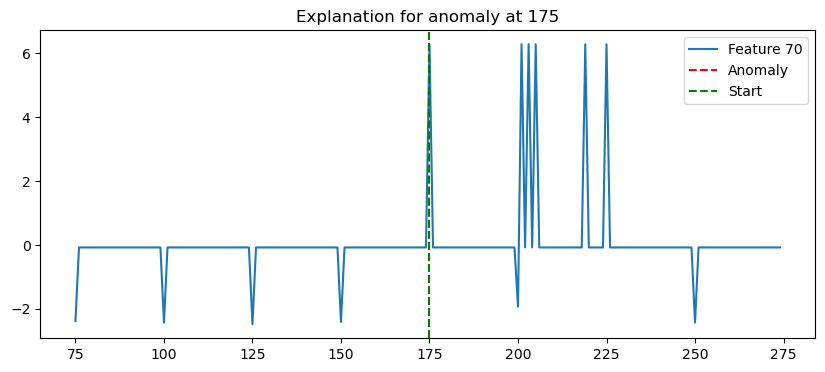


Anomaly at time 225
Most deviating feature: 78
Deviation value: 7.953
Anomaly likely started at: 225


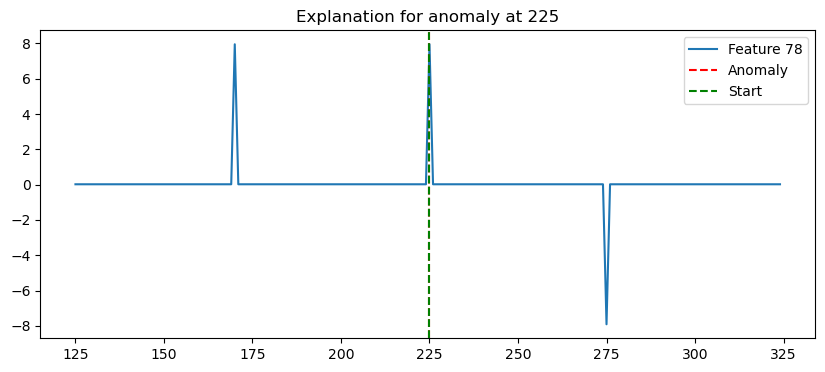


Anomaly at time 275
Most deviating feature: 10
Deviation value: 12.230
Anomaly likely started at: 275


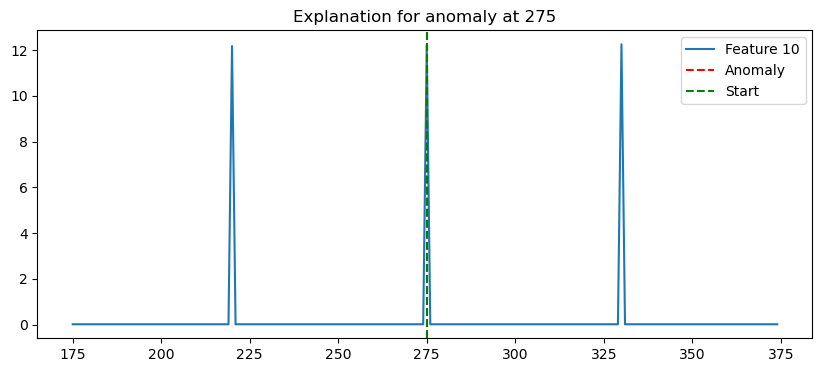

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Compute baseline (normal behavior)
# -----------------------------

mean_vals = np.mean(data_scaled, axis=0)


# -----------------------------
# 2. Get anomaly indices
# -----------------------------

anomaly_idx = np.where(anomaly == 1)[0]

print("Total anomalies:", len(anomaly_idx))


# -----------------------------
# 3. Explain a few anomalies
# -----------------------------

num_to_explain = 5  # change if needed

for idx in anomaly_idx[:num_to_explain]:

    # -----------------------------
    # Feature deviation
    # -----------------------------
    
    deviations = np.abs(data_scaled[idx] - mean_vals)
    
    # Feature with max deviation
    max_feat = np.argmax(deviations)
    
    print(f"\nAnomaly at time {idx}")
    print(f"Most deviating feature: {max_feat}")
    print(f"Deviation value: {deviations[max_feat]:.3f}")
    
    
    # -----------------------------
    # Find anomaly start (backward)
    # -----------------------------
    
    threshold = 1.5  # tune this
    
    start = idx
    
    for t in range(idx, 0, -1):
        dev = np.abs(data_scaled[t] - mean_vals)
        
        if dev[max_feat] < threshold:
            break
        
        start = t

    print(f"Anomaly likely started at: {start}")
    
    
    # -----------------------------
    # Visualization
    # -----------------------------
    
    window = 100
    
    left = max(0, idx - window)
    right = min(len(data_scaled), idx + window)
    
    plt.figure(figsize=(10,4))
    
    # Plot only the responsible feature
    plt.plot(range(left, right), 
             data_scaled[left:right, max_feat], 
             label=f"Feature {max_feat}")
    
    # Mark anomaly point
    plt.axvline(idx, color='red', linestyle='--', label="Anomaly")
    
    # Mark start point
    plt.axvline(start, color='green', linestyle='--', label="Start")
    
    plt.title(f"Explanation for anomaly at {idx}")
    plt.legend()
    plt.show()

Original shape: (2123, 23)
After cleaning: (2123, 22)
Adjusted shape: (2123, 82)
OPS anomalies detected: 0


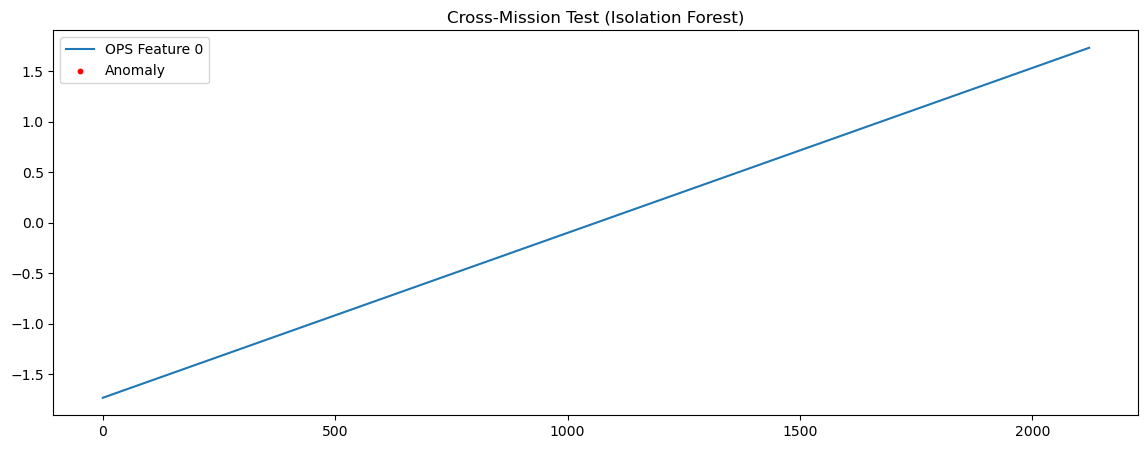

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. LOAD OPS-SAT DATA
# -----------------------------

ops_path = r"C:\\Users\\aryan\\Downloads\\OPS-SAT Dataset2\\dataset.csv"
ops_data = pd.read_csv(ops_path)

print("Original shape:", ops_data.shape)


# -----------------------------
# 2. KEEP ONLY NUMERIC FEATURES
# -----------------------------

ops_data = ops_data.select_dtypes(include=['float64', 'int64'])

print("After cleaning:", ops_data.shape)


# -----------------------------
# 3. MATCH FEATURE SIZE WITH SMAP
# -----------------------------

num_features_smap = data_scaled.shape[1]

if ops_data.shape[1] > num_features_smap:
    ops_data = ops_data.iloc[:, :num_features_smap]
else:
    pad_cols = num_features_smap - ops_data.shape[1]
    ops_data = np.hstack([ops_data, np.zeros((ops_data.shape[0], pad_cols))])

print("Adjusted shape:", ops_data.shape)


# -----------------------------
# 4. NORMALIZE
# -----------------------------

scaler_ops = StandardScaler()
ops_scaled = scaler_ops.fit_transform(ops_data)


# -----------------------------
# 5. APPLY ISOLATION FOREST (trained on SMAP)
# -----------------------------

ops_preds = model.predict(ops_scaled)   # model = IsolationForest

ops_anomaly = np.where(ops_preds == -1, 1, 0)

print("OPS anomalies detected:", np.sum(ops_anomaly))


# -----------------------------
# 6. VISUALIZATION
# -----------------------------

plt.figure(figsize=(14,5))

plt.plot(ops_scaled[:, 0], label="OPS Feature 0")

idx = np.where(ops_anomaly == 1)[0]

plt.scatter(idx, ops_scaled[idx, 0], color='red', s=10, label="Anomaly")

plt.title("Cross-Mission Test (Isolation Forest)")
plt.legend()
plt.show()

In [26]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. PREPARE DATA
# -----------------------------

# assume data = (time_steps, features)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# create sequences
def create_sequences(data, seq_len):
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)

SEQ_LEN = 50
X = create_sequences(data_scaled, SEQ_LEN)

print("Sequence shape:", X.shape)

# convert to tensor
X = torch.tensor(X, dtype=torch.float32)


# -----------------------------
# 2. MODEL
# -----------------------------

class LSTMAE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(LSTMAE, self).__init__()
        
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        
        # repeat hidden for each timestep
        hidden = hidden.repeat(x.size(1), 1, 1).permute(1,0,2)
        
        out, _ = self.decoder(hidden)
        return out


input_dim = X.shape[2]
model = LSTMAE(input_dim, hidden_dim=32)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# -----------------------------
# 3. TRAIN
# -----------------------------

EPOCHS = 5

for epoch in range(EPOCHS):
    output = model(X)
    loss = criterion(output, X)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


# -----------------------------
# 4. RECONSTRUCTION ERROR
# -----------------------------

with torch.no_grad():
    output = model(X)
    errors = torch.mean((X - output)**2, dim=(1,2)).numpy()


# -----------------------------
# 5. ANOMALY DETECTION
# -----------------------------

threshold = np.percentile(errors, 95)

anomaly_lstm = (errors > threshold).astype(int)

print("LSTM anomalies:", np.sum(anomaly_lstm))

Sequence shape: (7750, 50, 82)
Epoch 1, Loss: 1.0021
Epoch 2, Loss: 1.0017
Epoch 3, Loss: 1.0013
Epoch 4, Loss: 1.0011
Epoch 5, Loss: 1.0008
LSTM anomalies: 388


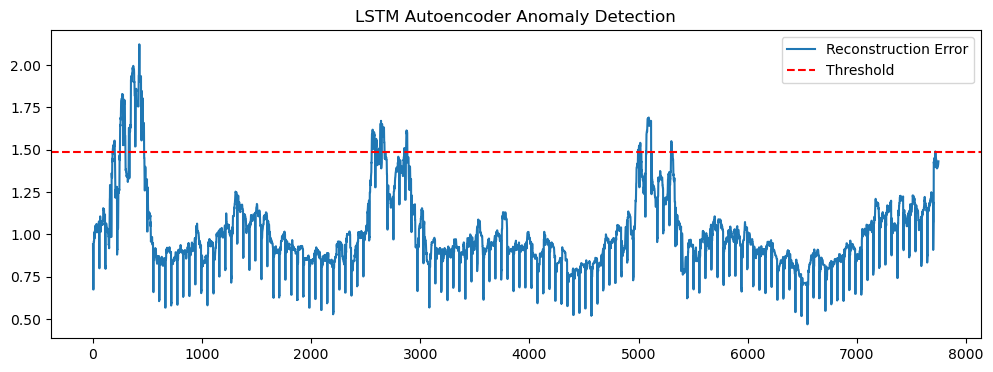

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(errors, label="Reconstruction Error")
plt.axhline(threshold, color='red', linestyle='--', label="Threshold")
plt.legend()
plt.title("LSTM Autoencoder Anomaly Detection")
plt.show()

Epoch 1, Loss: 120.6849
Epoch 2, Loss: 119.4056
Epoch 3, Loss: 119.0605
Epoch 4, Loss: 119.0143
Epoch 5, Loss: 118.6516
Epoch 6, Loss: 118.5611
Epoch 7, Loss: 118.4421
Epoch 8, Loss: 117.4104
Epoch 9, Loss: 108.5603
Epoch 10, Loss: 103.2156
Epoch 11, Loss: 102.1662
Epoch 12, Loss: 99.8555
Epoch 13, Loss: 98.3797
Epoch 14, Loss: 99.7319
Epoch 15, Loss: 98.1269
LSTM anomalies: 78


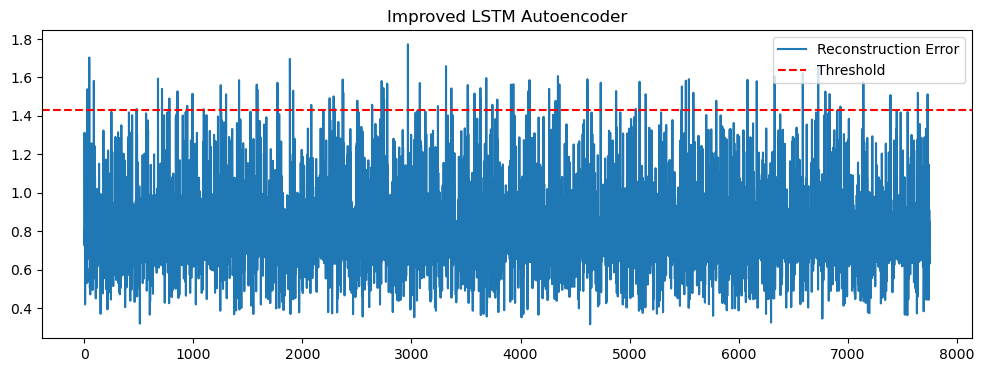

In [35]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------
# 1. PREPROCESS
# -----------------------------

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# create sequences
def create_sequences(data, seq_len):
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)

SEQ_LEN = 50
X = create_sequences(data_scaled, SEQ_LEN)

X = torch.tensor(X, dtype=torch.float32)

# dataset + loader
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=64, shuffle=True)


# -----------------------------
# 2. IMPROVED MODEL
# -----------------------------

class LSTMAE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.encoder = nn.LSTM(input_dim, 64, batch_first=True)
        self.encoder2 = nn.LSTM(64, 32, batch_first=True)
        
        self.decoder1 = nn.LSTM(32, 64, batch_first=True)
        self.decoder2 = nn.LSTM(64, input_dim, batch_first=True)

    def forward(self, x):
        x, _ = self.encoder(x)
        x, (hidden, _) = self.encoder2(x)
        
        # repeat hidden state
        hidden = hidden.repeat(x.size(1), 1, 1).permute(1,0,2)
        
        x, _ = self.decoder1(hidden)
        x, _ = self.decoder2(x)
        
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMAE(input_dim=X.shape[2]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# -----------------------------
# 3. TRAIN (BETTER)
# -----------------------------

EPOCHS = 15

for epoch in range(EPOCHS):
    total_loss = 0
    
    for batch in loader:
        batch_x = batch[0].to(device)
        
        output = model(batch_x)
        loss = criterion(output, batch_x)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


# -----------------------------
# 4. RECONSTRUCTION ERROR
# -----------------------------

model.eval()
errors = []

with torch.no_grad():
    for batch in loader:
        batch_x = batch[0].to(device)
        output = model(batch_x)
        
        err = torch.mean((batch_x - output)**2, dim=(1,2))
        errors.extend(err.cpu().numpy())

errors = np.array(errors)


# -----------------------------
# 5. THRESHOLD (BETTER)
# -----------------------------

threshold = np.percentile(errors, 99)

anomaly_lstm = (errors > threshold).astype(int)

print("LSTM anomalies:", np.sum(anomaly_lstm))


# -----------------------------
# 6. VISUALIZATION
# -----------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(errors, label="Reconstruction Error")
plt.axhline(threshold, color='red', linestyle='--', label="Threshold")
plt.legend()
plt.title("Improved LSTM Autoencoder")
plt.show()

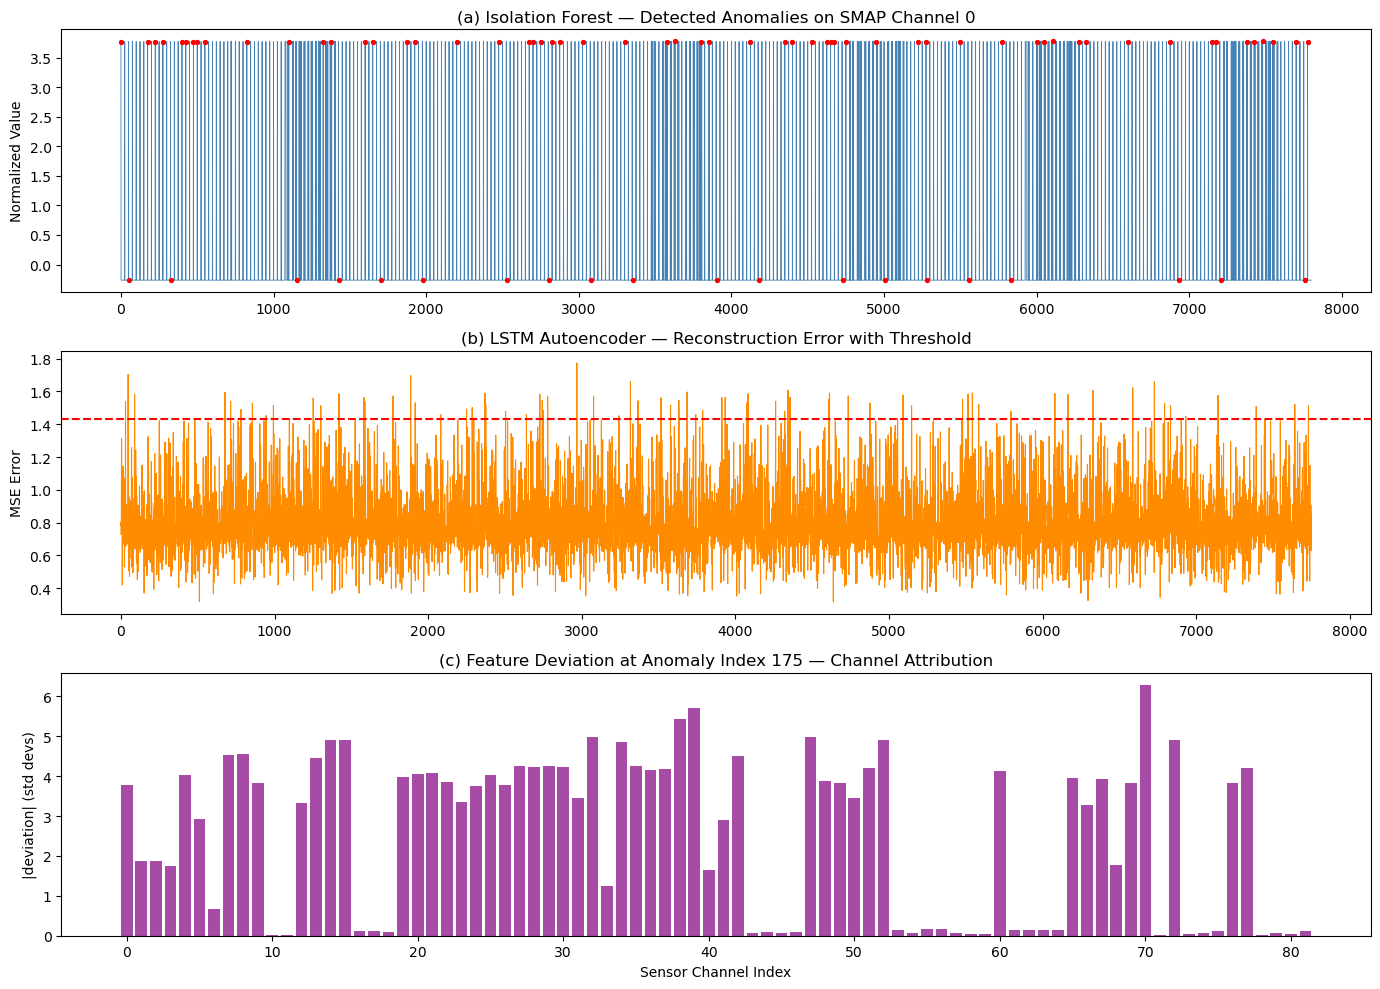

In [39]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: Isolation Forest anomalies
axes[0].plot(data_scaled[:, 0], color='steelblue', lw=0.6)
axes[0].scatter(np.where(anomaly==1)[0],
                data_scaled[np.where(anomaly==1)[0], 0],
                color='red', s=8, zorder=5)
axes[0].set_title('(a) Isolation Forest — Detected Anomalies on SMAP Channel 0')
axes[0].set_ylabel('Normalized Value')

# Panel 2: LSTM reconstruction error
axes[1].plot(errors, color='darkorange', lw=0.8)
axes[1].axhline(threshold, color='red', linestyle='--', lw=1.5)
axes[1].set_title('(b) LSTM Autoencoder — Reconstruction Error with Threshold')
axes[1].set_ylabel('MSE Error')

# Panel 3: Feature deviation for top anomaly
axes[2].bar(range(len(mean_vals)),
            np.abs(data_scaled[anomaly_idx[2]] - mean_vals),
            color='purple', alpha=0.7)
axes[2].set_title('(c) Feature Deviation at Anomaly Index 175 — Channel Attribution')
axes[2].set_xlabel('Sensor Channel Index')
axes[2].set_ylabel('|deviation| (std devs)')

plt.tight_layout()
plt.savefig('figure2_results.png', dpi=150, bbox_inches='tight')
plt.savefig('plot.png')
plt.show()